In [16]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict, Annotated
from langchain_core.messages import  BaseMessage , HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [17]:
load_dotenv()

True

In [18]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [19]:
from langchain_ollama import ChatOllama

model = ChatOllama(
    model="qwen3:8b",
    temperature=0,
    think=False
)

In [20]:
def chat_node(state:ChatState):
    messages=state['messages']
    response= model.invoke(messages)
    return {
        'messages':[response]
    }

In [21]:
graph= StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_edge(START,"chat_node")
graph.add_edge("chat_node",END)
chatbot=graph.compile()

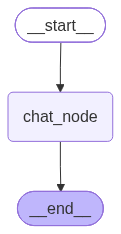

In [22]:
chatbot

In [23]:
initial_state={
 'messages':[HumanMessage(content ="what is capital of india")]
}

In [10]:
result= chatbot.invoke(initial_state)

In [13]:
result['messages'][-1].content

"The capital of India is **New Delhi**. It is the seat of the Government of India, home to the Parliament of India, and the location of key national institutions such as the Supreme Court and the President's residence (Rashtrapati Bhavan). New Delhi is also part of the **National Capital Territory (NCT) of Delhi**, which has a unique administrative status. While it is often confused with **Delhi** (the city name), New Delhi refers specifically to the central district of the NCT, where the political and administrative core of the country is located."

In [29]:
messages=[]
while True:
     user_input= input('Type here :  ')
     if user_input.strip().lower() in ['exit','bye','quit']:
         break
     else:    
         messages.append(HumanMessage(content= user_input))
         initial_state={
         'messages':messages
          }
         messages= chatbot.invoke(initial_state)['messages']
         print(messages)

Type here :   add 10 to 20


[HumanMessage(content='add 10 to 20', additional_kwargs={}, response_metadata={}, id='81599aa7-20ad-47e2-a053-d4ab2edb9118'), AIMessage(content='The result of adding 10 to 20 is **30**. \n\n**Step-by-Step Explanation:**\n1. Start with the number 20.\n2. Add 10 to it: $ 20 + 10 $.\n3. Perform the addition: $ 20 + 10 = 30 $.\n\n**Answer:** 30', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-09-22T18:20:00.6795318Z', 'done': True, 'done_reason': 'stop', 'total_duration': 127987926900, 'load_duration': 12874183200, 'prompt_eval_count': 18, 'prompt_eval_duration': 394152000, 'eval_count': 493, 'eval_duration': 114706559000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--01a0ca56-ab32-7832-ba09-cc88a732cbdb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 493, 'total_tokens': 511})]


Type here :   now add 10 to this answer


[HumanMessage(content='add 10 to 20', additional_kwargs={}, response_metadata={}, id='81599aa7-20ad-47e2-a053-d4ab2edb9118'), AIMessage(content='The result of adding 10 to 20 is **30**. \n\n**Step-by-Step Explanation:**\n1. Start with the number 20.\n2. Add 10 to it: $ 20 + 10 $.\n3. Perform the addition: $ 20 + 10 = 30 $.\n\n**Answer:** 30', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-09-22T18:20:00.6795318Z', 'done': True, 'done_reason': 'stop', 'total_duration': 127987926900, 'load_duration': 12874183200, 'prompt_eval_count': 18, 'prompt_eval_duration': 394152000, 'eval_count': 493, 'eval_duration': 114706559000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--01a0ca56-ab32-7832-ba09-cc88a732cbdb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 493, 'total_tokens': 511}), HumanMessage(content='now add 10 to this answer', additional_kwargs={}, response_metadata={},

Type here :   exit


In [28]:
messages[-1].content

'Madrid is the **capital and largest city of Spain**, located in the central part of the country. It is a vibrant metropolis that blends historical significance, cultural richness, and modern urban life. Here’s an overview of Madrid:\n\n---\n\n### **History**  \nMadrid became the capital of Spain in **1561** when King Philip II moved the royal court from Toledo to the city. Its strategic location in the heart of Spain made it a natural political and economic hub. The city has a long history of cultural and artistic influence, with its architecture and traditions shaped by centuries of Spanish history, including the Moorish, Roman, and Renaissance periods.\n\n---\n\n### **Geography**  \n- **Location**: Madrid is situated in the **Central Plateau** of Spain, surrounded by the **Guadarrama Mountains** to the north.  \n- **River**: The **Manzanares River** flows through the city, dividing it into two main areas: the **Old Madrid** (historic center) and the **New Madrid** (modern districts)